In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from cellpose import models, io
from skimage.filters import (
    threshold_otsu,
    threshold_yen,
    threshold_triangle,
    threshold_li,
    threshold_isodata
)

# Settings
file_idx = 3                     # 0 = first file, 1 = second file, etc.
model_type = "cyto3"              # try different models for segmentation: "cyto", "cyto2", "cyto3", "nuclei"
diameter = None                  # None lets Cellpose estimate size
channels = [0, 0]                # [0,0] for grayscale
use_gpu = False                  # set True if you have GPU working
save_masks = False               # True if you want to save output
input_dir = "../data/separated_frames"

Using file index 3: ch20_URA7_URA8_001-crop1_frame_11.tiff
Image shape: (128, 128), dtype: uint16
otsu 146
yen 150
triangle 144
li 139.83380548563423
isodata 145
Using method: percentile
Threshold value: 205.0
Percentile: 99.95
Estimated diameter: 30
Number of segmented objects: 0


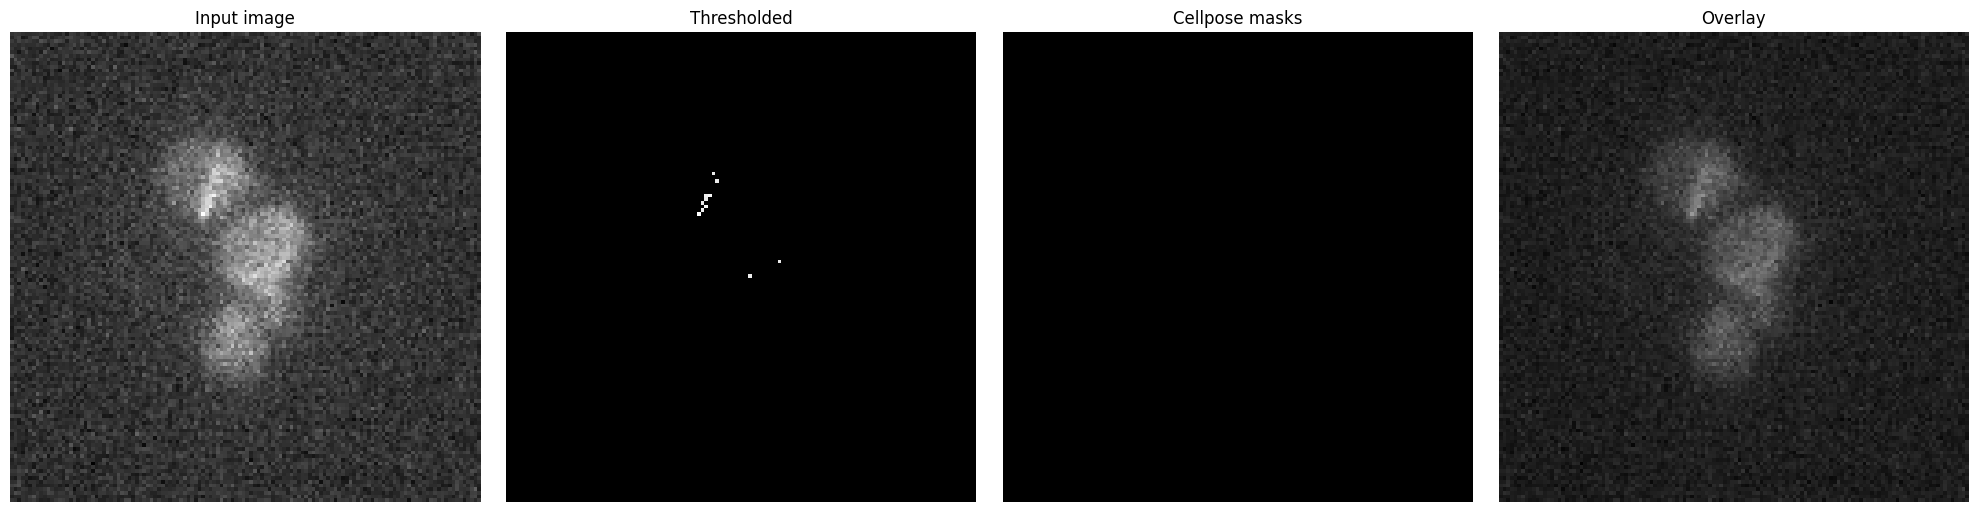

In [50]:
# Getting file list
files = sorted([
    f for f in os.listdir(input_dir)
    if f.lower().endswith((".tif", ".tiff"))
])

if not files:
    raise ValueError(f"No TIFF files found in {input_dir}")

if file_idx < 0 or file_idx >= len(files):
    raise IndexError(f"file_idx {file_idx} is out of range. Found {len(files)} files.")

file_name = files[file_idx]
file_path = os.path.join(input_dir, file_name)

print(f"Using file index {file_idx}: {file_name}")

# Loading image
img = imread(file_path)
print(f"Image shape: {img.shape}, dtype: {img.dtype}")

# Threshold options
import numpy as np

# Threshold options
methods = {
    "otsu": threshold_otsu,
    "yen": threshold_yen,
    "triangle": threshold_triangle,
    "li": threshold_li,
    "isodata": threshold_isodata,
    "manual": None,
    "percentile": None,
}

method = "percentile"   # <<< choose here

manual_th = 200         # used if method == "manual"
percentile_val = 99.95     # used if method == "percentile"

# Print automatic thresholds
for name, func in methods.items():
    if func is not None:
        print(name, func(img))

# Apply chosen method
if method == "manual":
    th = manual_th

elif method == "percentile":
    th = np.percentile(img, percentile_val)

else:
    th = methods[method](img)

img_thresh = img.copy()
img_thresh[img < th] = 0

print(f"Using method: {method}")
print(f"Threshold value: {th}")

if method == "percentile":
    print(f"Percentile: {percentile_val}")

# Running cellpose
model = models.Cellpose(gpu=use_gpu, model_type=model_type)

masks, flows, styles, diams = model.eval(
    img_thresh,
    diameter=diameter,
    channels=channels
)

print(f"Estimated diameter: {diams}")
print(f"Number of segmented objects: {masks.max()}")

# Showing results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(img_thresh, cmap="gray")
axes[1].set_title("Thresholded")
axes[1].axis("off")

axes[2].imshow(masks, cmap="nipy_spectral")
axes[2].set_title("Cellpose masks")
axes[2].axis("off")

axes[3].imshow(img, cmap="gray")
axes[3].imshow(masks, cmap="nipy_spectral", alpha=0.4)
axes[3].set_title("Overlay")
axes[3].axis("off")

plt.tight_layout()
plt.show()